# Polynomial Regression — Car Speed vs Braking Distance (USA)

**Dataset:** This dataset contains road safety data from the USA. It includes `speed_mph` (car speed in miles per hour) and `braking_distance_ft` (the distance in feet that the car travels after the brakes are applied until it stops).

**Description:** This dataset has a **non-linear (curved) relationship**. In real-world physics, the braking distance is approximately proportional to the **square of the car's speed**. This means that if the speed doubles, the braking distance becomes about **four times longer**. This dataset is different from the Pakistan house price dataset because it comes from the **USA** and clearly shows a curved pattern, making it a good example for **Polynomial Regression**.

**Formula (Degree = 2):** `distance = b0 + b1*speed + b2*speed^2`


## 1. Libraries aur Dataset Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

df = pd.read_csv('usa_car_speed_braking_distance.csv')
df.head()

,speed_mph,braking_distance_ft
0,16.1,14.1
1,72.4,342.8
2,45.1,149.1
3,67.9,302.0
4,88.2,479.5


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   speed_mph            250 non-null    float64
 1   braking_distance_ft  250 non-null    float64
dtypes: float64(2)
memory usage: 4.0 KB


,speed_mph,braking_distance_ft
count,250.000000,250.000000
mean,50.065600,200.654800
std,22.705266,142.118128
min,10.100000,5.000000
25%,31.750000,76.950000
50%,49.650000,168.450000
75%,70.150000,319.575000
max,89.400000,506.900000


## 2. Data Visualization (Before Training)

Pehle raw data dekhte hain — curve clearly nazar aayega.

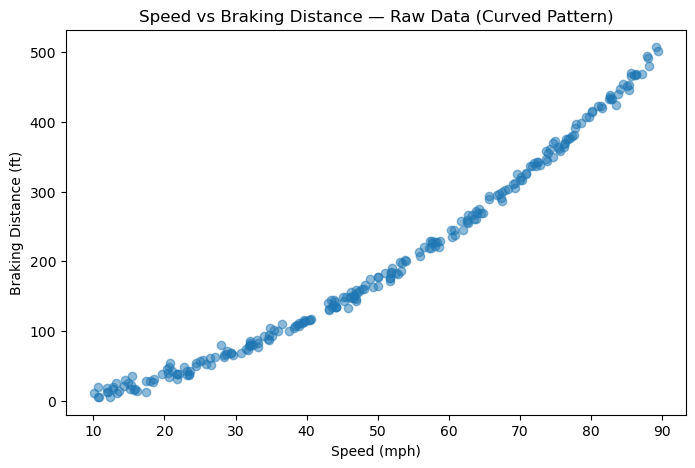

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(df['speed_mph'], df['braking_distance_ft'], alpha=0.5)
plt.xlabel('Speed (mph)')
plt.ylabel('Braking Distance (ft)')
plt.title('Speed vs Braking Distance — Raw Data (Curved Pattern)')
plt.show()

## 3. Comparison: Simple Linear Fit vs Polynomial Fit

Pehle dekhte hain agar hum simple (straight-line) fit karein to kya hota hai, phir polynomial (degree=2) fit karein.

In [5]:
X = df[['speed_mph']]
y = df['braking_distance_ft']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Simple (linear) fit for comparison ---
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
preds_linear = linear_model.predict(X_test)

print("Straight-Line (Simple Linear) Fit:")
print(f"  R2 Score : {r2_score(y_test, preds_linear):.4f}")
print(f"  MAE      : {mean_absolute_error(y_test, preds_linear):.2f} ft")

Straight-Line (Simple Linear) Fit:
  R2 Score : 0.9611
  MAE      : 25.01 ft


## 4. Polynomial Regression (Degree = 2) Training

In [6]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

preds_poly = poly_model.predict(X_test_poly)

print(f"Equation : distance = {poly_model.intercept_:.3f} + ({poly_model.coef_[0]:.3f}*speed) + ({poly_model.coef_[1]:.4f}*speed^2)")
print(f"R2 Score : {r2_score(y_test, preds_poly):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, preds_poly):.2f} ft")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, preds_poly)):.2f} ft")

Equation : distance = -4.085 + (0.849*speed) + (0.0536*speed^2)
R2 Score : 0.9983
MAE      : 4.94 ft
RMSE     : 6.20 ft


## 5. Visualization — Linear vs Polynomial Fit Comparison

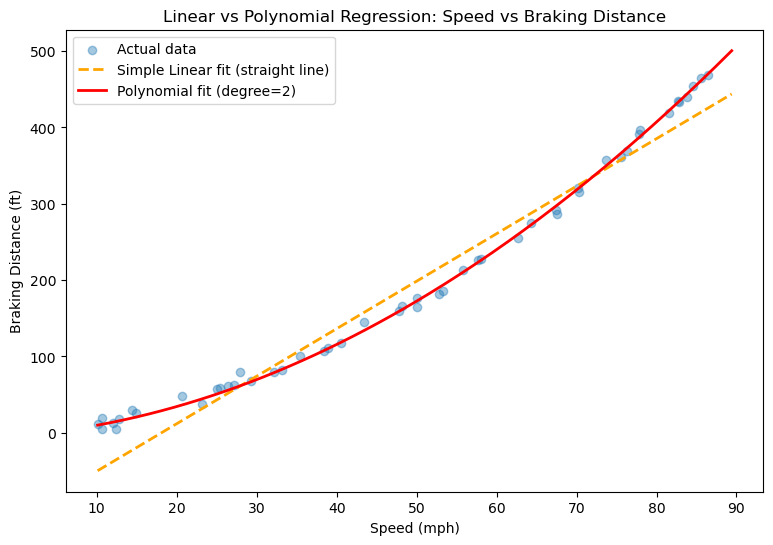

In [7]:
plt.figure(figsize=(9,6))
plt.scatter(X_test, y_test, alpha=0.4, label='Actual data')

speed_range = np.linspace(X['speed_mph'].min(), X['speed_mph'].max(), 200).reshape(-1,1)
speed_range_df = pd.DataFrame(speed_range, columns=['speed_mph'])

# linear line
linear_curve = linear_model.predict(speed_range_df)
plt.plot(speed_range, linear_curve, color='orange', linewidth=2, linestyle='--', label='Simple Linear fit (straight line)')

# polynomial curve
speed_range_poly = poly.transform(speed_range_df)
poly_curve = poly_model.predict(speed_range_poly)
plt.plot(speed_range, poly_curve, color='red', linewidth=2, label='Polynomial fit (degree=2)')

plt.xlabel('Speed (mph)')
plt.ylabel('Braking Distance (ft)')
plt.title('Linear vs Polynomial Regression: Speed vs Braking Distance')
plt.legend()
plt.show()

## 6. New Value Prediction

Ab naye speed values dekar braking distance predict karte hain, aur linear vs polynomial ka farq bhi dekhte hain.

In [8]:
print(f"{'Speed (mph)':>12} | {'Linear Pred (ft)':>18} | {'Polynomial Pred (ft)':>20}")
print('-'*56)
for speed in [20, 40, 60, 80, 100]:
    s_df = pd.DataFrame({'speed_mph':[speed]})
    lin_p = linear_model.predict(s_df)[0]
    poly_p = poly_model.predict(poly.transform(s_df))[0]
    print(f"{speed:>12} | {lin_p:>18.2f} | {poly_p:>20.2f}")

 Speed (mph) |   Linear Pred (ft) | Polynomial Pred (ft)
--------------------------------------------------------
          20 |              11.86 |                34.35
          40 |             136.35 |               115.70
          60 |             260.83 |               239.96
          80 |             385.31 |               407.14
         100 |             509.80 |               617.23


## 7. Summary

* The relationship between **speed** and **braking distance** is **not linear**. It follows a **curved pattern**, which means that as the speed increases, the braking distance increases much faster.
* **Polynomial Regression (Degree = 2)** captures this curved relationship much better than **Simple Linear Regression**, resulting in a **higher R² score** and **lower prediction error**.
* At high speeds (such as **80–100 mph**), a Simple Linear Regression model usually **underestimates the braking distance**, which can be unsafe in real-world situations. This example shows that when the data has a **true curved relationship**, **Polynomial Regression** provides more accurate and reliable predictions.
